# DS300 Movie Recommender
### To run this project you must add the dataset `title.ratings.tsv.gz` from https://datasets.imdbws.com/ to the local directory

In [1]:
import pandas as pd
from letterboxd_utils import clean_diary_data, remove_duplicate_movies, get_tmdb_data, fetch_imdb_ratings, get_user_diary, get_movie_recommendations, engineer_features_for_knn, train_and_evaluate_knn, plot_model_analysis

/var/folders/sh/9y2x7hyx76bghklsygtm6m000000gn/T/ipykernel_54683/3540019096.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Input username of desired profile

In [2]:
username = 'kmgrimes'

## Data Curation and Feature Engineering

In [3]:
df, film_slug_list = get_user_diary(username)
df = clean_diary_data(df)
df = remove_duplicate_movies(df)

In [4]:
movies_df = pd.DataFrame({
    'Film': df['Film'],
    'Released': df['Released']
})

tmdb_data = get_tmdb_data(movies_df, '4891dd286064835e1f235e7ab4f52baa')

In [5]:
tmdb_data

,Original Title,TMDB ID,IMDb ID,Budget,Revenue,TMDB Rating,TMDB Vote Count,Popularity,Genres,Adult
0,Gladiator II,558449,tt9218128,310000000,329092895,6.665,982,1248.855,"Action, Adventure, History",False
1,Wicked,402431,tt1262426,150000000,455551000,7.586,457,1055.820,"Drama, Romance, Fantasy",False
2,The Hangover,18785,tt1119646,35000000,469310836,7.323,16827,122.008,Comedy,False
3,Don't Move,1063877,tt24807110,0,0,6.423,572,244.502,"Thriller, Horror",False
4,Piece By Piece,1236419,tt31064841,16000000,10291872,7.800,59,36.743,"Animation, Music, Documentary",False
...,...,...,...,...,...,...,...,...,...,...
177,But I'm a Cheerleader,20770,tt0179116,1200000,2600000,7.000,672,21.460,"Comedy, Romance",False
178,Maurice,26371,tt0093512,2600000,2438304,7.600,534,14.356,"Drama, Romance",False
179,Ponyo,12429,tt0876563,34000000,202404009,7.740,4295,42.280,"Animation, Fantasy, Family",False
180,Open Season,7484,tt0400717,85000000,197300000,6.155,2729,30.123,"Animation, Family, Adventure, Comedy",False


In [6]:
# Adding user ratings from Letterboxd diary to the tmdb_data
tmdb_data['User Rating'] = df['Ratings']

# Add IMDb ratings
imdb_ratings = fetch_imdb_ratings(tmdb_data)
tmdb_data['IMDb Rating'] = imdb_ratings

### Train and Show Results!

In [7]:
# Process data
processed_data, scaler = engineer_features_for_knn(tmdb_data)

# Prepare X and y
y = tmdb_data['User Rating'].values
X = processed_data.values

# Train and evaluate
model = train_and_evaluate_knn(X, y)

MSE: 0.564
R squared: 0.275
Accuracy (plus minus 0.5 stars): 0.568
Accuracy (plus minus 1 star): 0.811


### Plotting for analysis

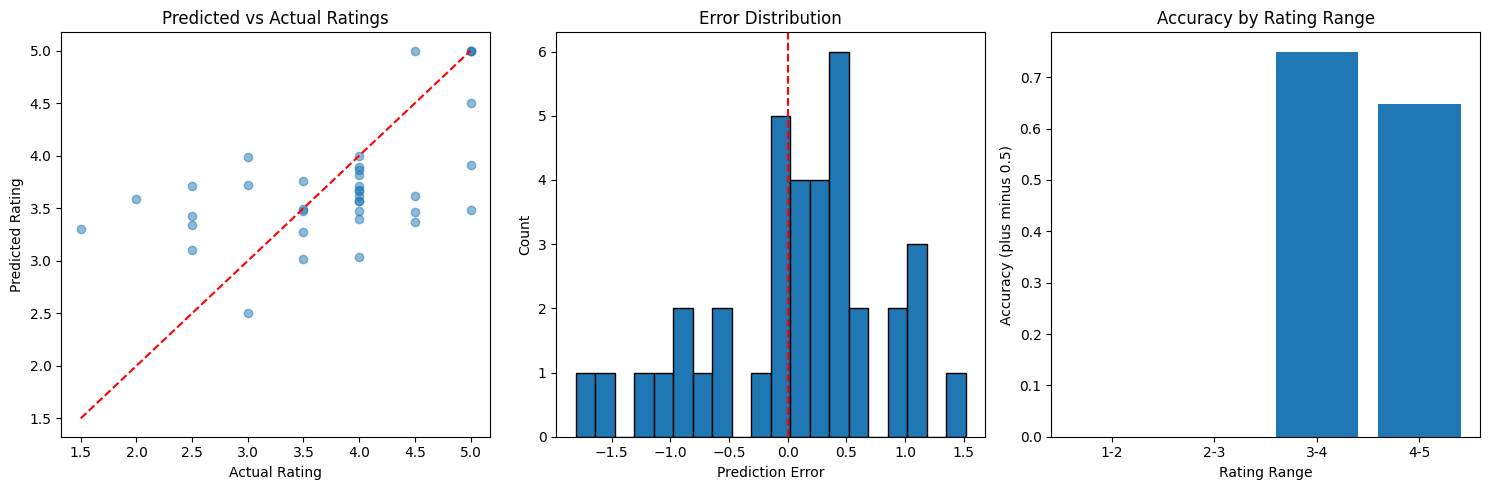

In [8]:
analysis_results = plot_model_analysis(model, X, y)

### Recommend some potential movies that user will love!

In [9]:
# Get the titles we used in training to avoid duplicates

used_titles = set(tmdb_data['Original Title'])

# Get recommendations
recommended_movies = get_movie_recommendations('4891dd286064835e1f235e7ab4f52baa', model, scaler, used_titles, 125)

if not recommended_movies.empty:
    print("\nRecommended Movies (Predicted 4.0+ stars):")
    print(recommended_movies.to_string(index=False))
else:
    print("No recommendations found.")

Fetching random movies...
Loading IMDb ratings...
Fetching movies...
Found 125/125 movies
Recommended Movies (Predicted 4.0+ stars):
                   Title  Predicted_Rating  TMDB Rating  IMDb Rating
The Shawshank Redemption          4.022370        8.708          9.3
           The Godfather          4.016567        8.689          9.2
           Despicable Me          4.015054        7.245          7.6


/Users/turalk/Desktop/NLP/Lab2_NLP/tf_env/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
